# ML-11 : le Matrix Profile multidimensionnel, une détection d'anomalies sans apprentissage

**Série ML.NET / Python -- volet 11.** Ce notebook fait suite à [ML-10](ML-10-TSAD-Benchmark-Flaws-Python.ipynb), qui démontait la
méthodologie des benchmarks de détection d'anomalies sur séries temporelles (TSAD). La
conclusion de ML-10 était inconfortable : une part importante des jeux de référence est
*triviale*, au sens où une règle de contrôle statistique élémentaire (la carte de contrôle
`M + 3s`) suffit à les résoudre. Les classements publiés mesurent alors la capacité des
modèles à surapprendre un benchmark facile, pas leur capacité à détecter des anomalies.

La question qui suit naturellement est : **quel outil résiste à cette critique ?**

La réponse étudiée ici est le **Matrix Profile** (MP). C'est une méthode *sans apprentissage* :
aucun paramètre n'est ajusté sur des données d'entraînement, donc il n'y a structurellement
rien à surapprendre. Un détecteur sans apprentissage ne peut pas tricher avec un benchmark
trivial -- il n'a pas de capacité d'absorption. C'est précisément la famille que la critique
de ML-10 laisse intacte.

Nous suivons **Yeh et al. (2024), *Matrix Profile for Anomaly Detection on Multidimensional
Time Series*** (arXiv:2409.09298), qui étend le Matrix Profile au cas **multidimensionnel** --
plusieurs capteurs observés simultanément -- et compare 19 méthodes de référence sur 119 jeux
de données TSAD dans trois régimes (non supervisé, supervisé, semi-supervisé). Leur résultat
central : le Matrix Profile est la seule méthode dont la performance reste *constante* sur
l'ensemble du protocole.

Une section annexe présente **Fu et al. (soumission ICLR 2025), *FMP-AE: A Hybrid Approach to
Time Series Anomaly Detection*** (OpenReview `fErm1seIom`), qui montre que le Matrix Profile
reste pertinent à l'ère de l'apprentissage profond -- non plus comme détecteur autonome, mais
comme **terme de perte structurée** régularisant un auto-encodeur.

***

## Ce que vous saurez faire à la fin

1. Calculer un Matrix Profile univarié avec la bibliothèque `stumpy` et en extraire les
   *discords* (les sous-séquences les plus atypiques).
2. Expliquer pourquoi une anomalie **contextuelle** échappe à une carte de contrôle
   ponctuelle, et pourquoi le Matrix Profile la voit.
3. Étendre le Matrix Profile à plusieurs dimensions, et surtout **choisir** entre les
   stratégies de condensation -- ce choix n'est pas un détail, il décide du résultat.
4. Comparer honnêtement Matrix Profile multidimensionnel, ACP (ML-9) et carte de contrôle
   (ML-10) sur une anomalie que deux des trois ne voient pas.
5. Situer le Matrix Profile dans une architecture profonde (FMP-AE).

## Prérequis

- **ML-9** ([ML-9-Anomaly-Detection-Python.ipynb](ML-9-Anomaly-Detection-Python.ipynb)) :
  détection d'anomalies par ACP et erreur de reconstruction. Nous reprenons ici son trio de
  capteurs (température, pression, vibration), mais **en version temporelle**.
- **ML-10** : critique méthodologique des benchmarks TSAD, carte de contrôle `M + 3s`. Le
  présent notebook en est la suite directe.
- Notions de base : moyenne, écart-type, distance euclidienne.

## Bibliothèque

Nous utilisons **`stumpy`**, l'implémentation de référence du Matrix Profile
(<https://stumpy.readme.io/>), adossée aux publications du groupe de Keogh. C'est le véritable
outil du domaine, pas une réimplémentation pédagogique : `stumpy` calcule le profil **exact**
via transformée de Fourier et le parallélisé avec Numba.

## Installation et versions

`stumpy` s'installe par `pip install stumpy`. La cellule suivante affiche les versions
effectivement chargées : c'est une habitude utile, car les résultats numériques d'un notebook
ne sont interprétables que si l'on sait avec quelles versions ils ont été produits. C'est aussi
la première ligne de défense contre le problème que ML-10 documentait -- un chiffre publié sans
son environnement n'est pas reproductible, il est seulement affirmé.

In [1]:
# Imports : stumpy pour le Matrix Profile, numpy pour les donnees,
# scikit-learn pour l'ACP de comparaison, matplotlib pour les figures.
from importlib.metadata import version

import numpy as np
import matplotlib.pyplot as plt
import stumpy
import sklearn
from sklearn.decomposition import PCA

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (11, 3.2)

print(f"numpy        {np.__version__}")
print(f"scikit-learn {sklearn.__version__}")
print(f"stumpy       {version('stumpy')}")
print(f"  stump  -> {stumpy.stump.__doc__.strip().splitlines()[0][:60]}")

numpy        2.4.6
scikit-learn 1.9.0
stumpy       1.14.1
  stump  -> Compute the z-normalized matrix profile


***

# Section 1 -- Le Matrix Profile univarié

## Définition

Soit une série temporelle `T` de longueur `n` et une longueur de fenêtre `m`. On appelle
**sous-séquence** `T[i:i+m]` la fenêtre glissante démarrant en `i` ; il y en a `l = n - m + 1`.

Le **Matrix Profile** est le vecteur `P` de longueur `l` défini par

> `P[i]` = distance euclidienne z-normalisée entre `T[i:i+m]` et sa **plus proche voisine non
> triviale** parmi toutes les autres sous-séquences de `T`.

« Non triviale » signifie que l'on exclut les voisines qui chevauchent `i` -- sans cela, chaque
sous-séquence serait sa propre voisine à distance nulle.

La **z-normalisation** mérite d'être relevée : chaque sous-séquence est centrée-réduite avant
comparaison. Le Matrix Profile compare donc des **formes**, pas des niveaux. Conséquence
immédiate et souvent contre-intuitive, que nous vérifierons plus loin : *un simple changement
d'amplitude est presque invisible au Matrix Profile*.

## Lecture du profil

- `P[i]` **faible** : la sous-séquence `i` a une jumelle ailleurs dans la série. C'est un
  **motif** -- un comportement répète, donc normal.
- `P[i]` **élevé** : la sous-séquence `i` n'a aucune voisine proche. Elle est structurellement
  unique. On l'appelle un **discord**, et c'est la définition d'anomalie retenue ici.

Le point remarquable est qu'il n'y a **aucun apprentissage** : pas de phase d'entraînement, pas
de paramètre ajusté, pas de jeu « normal » à fournir. Le seul hyperparamètre est `m`, la
longueur de fenêtre, qui encode l'échelle à laquelle on cherche une anomalie. C'est cette
absence d'apprentissage qui rend la méthode immune à la critique de ML-10 : il n'y a rien à
surapprendre, donc rien à surapprendre *de travers*.

## Le jeu de données de la section 1

Nous fabriquons une série de capteur portant une anomalie **contextuelle** : sur une fenêtre
donnée, la **cadence** du signal change (le cycle s'accélère), mais **aucune valeur ne sort de
la plage habituelle**. C'est le cas d'école que la carte de contrôle ne peut pas voir, puisque
celle-ci n'examine que la valeur de chaque point isolement, jamais l'ordre des points.

In [2]:
# --- Serie 1 : un capteur unique, anomalie CONTEXTUELLE (changement de cadence) ---
FS = 20              # points par cycle nominal
N1 = 1600            # longueur de la serie
ANOM1 = (900, 980)   # fenetre anormale : la cadence y est acceleree

rng1 = np.random.default_rng(2026)

# Frequence instantanee : 1 partout, acceleree dans la fenetre anormale.
freq1 = np.ones(N1)
freq1[ANOM1[0]:ANOM1[1]] = 1.9

# La phase est l'integrale de la frequence : cela garantit un signal CONTINU,
# sans saut artificiel qu'un simple seuil trahirait.
phase1 = np.cumsum(2 * np.pi * freq1 / FS)
serie1 = 20.0 + 3.0 * np.sin(phase1) + rng1.normal(0, 0.25, N1)

hors = np.delete(serie1, np.s_[ANOM1[0]:ANOM1[1]])
dans = serie1[slice(*ANOM1)]

print(f"Serie 1 : {N1} points | anomalie sur [{ANOM1[0]}, {ANOM1[1]}) "
      f"= {ANOM1[1]-ANOM1[0]} points ({100*(ANOM1[1]-ANOM1[0])/N1:.1f}% de la serie)")
print(f"  Plage hors anomalie   : [{hors.min():6.2f}, {hors.max():6.2f}]   moyenne {hors.mean():.3f}   ecart-type {hors.std():.3f}")
print(f"  Plage dans l'anomalie : [{dans.min():6.2f}, {dans.max():6.2f}]   moyenne {dans.mean():.3f}   ecart-type {dans.std():.3f}")

Serie 1 : 1600 points | anomalie sur [900, 980) = 80 points (5.0% de la serie)
  Plage hors anomalie   : [ 16.37,  23.67]   moyenne 19.996   ecart-type 2.136
  Plage dans l'anomalie : [ 16.72,  23.36]   moyenne 20.071   ecart-type 2.180


### Lecture du résultat

Les deux plages de valeurs se recouvrent, et moyennes comme écarts-types coïncident à quelques
centièmes. C'est voulu, et c'est tout l'enjeu : **l'anomalie ne se lit pas dans la distribution
des valeurs**. Elle n'existe que dans l'*ordre* des valeurs -- le signal oscille plus vite
pendant 80 points, sans jamais sortir de sa plage.

Cette propriété a une conséquence formelle qu'il faut garder en tête pour tout le notebook :
tout détecteur qui traite les points **indépendamment les uns des autres** est *invariant par
permutation*. Or permuter les points de cette série ne modifie pas l'ensemble des valeurs
présentes. Un tel détecteur ne peut donc pas, même en principe, distinguer la fenêtre anormale
du reste. Ce n'est pas une question de réglage ni de puissance statistique : c'est une
impossibilité structurelle.

La carte de contrôle `M + 3s` de ML-10 est exactement de ce type. Vérifions-le plutôt que de
l'affirmer.

In [3]:
# --- Carte de controle M + 3s (methode de ML-10) appliquee a la serie 1 ---
mu, sigma = serie1.mean(), serie1.std()
z_scores = np.abs((serie1 - mu) / sigma)
SEUIL_SPC = 3.0

alertes = np.flatnonzero(z_scores > SEUIL_SPC)
dans_anomalie = alertes[(alertes >= ANOM1[0]) & (alertes < ANOM1[1])]

print(f"Carte de controle : mu={mu:.3f}  sigma={sigma:.3f}  seuil |z| > {SEUIL_SPC}")
print(f"  Alertes sur toute la serie          : {alertes.size}")
print(f"  Alertes DANS la fenetre anormale    : {dans_anomalie.size} / {ANOM1[1]-ANOM1[0]} points")
print(f"  |z| maximal DANS la fenetre         : {z_scores[slice(*ANOM1)].max():.3f}")
print(f"  |z| maximal HORS de la fenetre      : {np.delete(z_scores, np.s_[ANOM1[0]:ANOM1[1]]).max():.3f}")

Carte de controle : mu=20.000  sigma=2.138  seuil |z| > 3.0
  Alertes sur toute la serie          : 0
  Alertes DANS la fenetre anormale    : 0 / 80 points
  |z| maximal DANS la fenetre         : 1.573
  |z| maximal HORS de la fenetre      : 1.714


### Lecture du résultat

La carte de contrôle ne déclenche **aucune** alerte, ni dans la fenêtre anormale ni ailleurs :
le `|z|` maximal à l'intérieur de l'anomalie est du même ordre que le maximum hors anomalie, et
les deux restent sous le seuil de 3. Le détecteur ne rate pas l'anomalie de peu -- il ne voit
strictement rien, exactement comme l'argument d'invariance par permutation le prévoyait.

C'est le point aveugle que ML-10 laissait en creux. ML-10 montrait qu'un benchmark rempli
d'anomalies *ponctuelles* est trivial, parce que la carte de contrôle le résout. La réciproque
est fausse : une anomalie contextuelle comme celle-ci est hors de portée de la carte de
contrôle, quelle que soit la finesse du seuil. « Trivial pour `M + 3s` » et « facile » ne sont
pas synonymes -- ce sont deux axes indépendants.

Voyons ce que le Matrix Profile en fait.

In [4]:
# --- Matrix Profile univarie via stumpy ---
M1 = 40   # fenetre = 2 cycles nominaux : l'echelle a laquelle une anomalie de cadence est visible

mp1 = stumpy.stump(serie1, M1)      # colonne 0 = distance au plus proche voisin
profil1 = mp1[:, 0].astype(float)
idx_voisin1 = mp1[:, 1].astype(int)  # colonne 1 = INDICE de ce plus proche voisin

discord1 = int(np.argmax(profil1))

print(f"Fenetre m = {M1} points ({M1/FS:.0f} cycles nominaux)")
print(f"Profil calcule : {profil1.size} sous-sequences")
print(f"  Distance mediane au plus proche voisin : {np.median(profil1):.3f}")
print(f"  Distance maximale (le discord)         : {profil1[discord1]:.3f}  a l'indice {discord1}")
print(f"  Le discord tombe-t-il dans [{ANOM1[0]}, {ANOM1[1]}) ? "
      f"{'OUI' if ANOM1[0] - M1 <= discord1 < ANOM1[1] else 'NON'}")
print(f"  Rapport discord / mediane : {profil1[discord1]/np.median(profil1):.1f}x")

Fenetre m = 40 points (2 cycles nominaux)
Profil calcule : 1561 sous-sequences
  Distance mediane au plus proche voisin : 0.799
  Distance maximale (le discord)         : 6.429  a l'indice 882
  Le discord tombe-t-il dans [900, 980) ? OUI
  Rapport discord / mediane : 8.0x


### Lecture du résultat

Le maximum du profil tombe dans la fenêtre anormale, et il la dépasse d'un facteur important
par rapport à la distance médiane. Là où la carte de contrôle ne produisait aucun signal, le
Matrix Profile produit un pic net -- sans avoir rien appris, sans qu'on lui ait dit où chercher
ni ce qu'est une anomalie.

Le mécanisme est simple à énoncer : pendant la fenêtre anormale, la forme locale du signal
(deux cycles comprimés au lieu d'un cycle) n'existe **nulle part ailleurs** dans la série. La
sous-séquence n'a donc pas de voisine proche, et sa distance au plus proche voisin explose.
Partout ailleurs, chaque fenêtre de deux cycles ressemble à des centaines d'autres, et la
distance reste faible.

La figure suivante superpose la série et son profil.

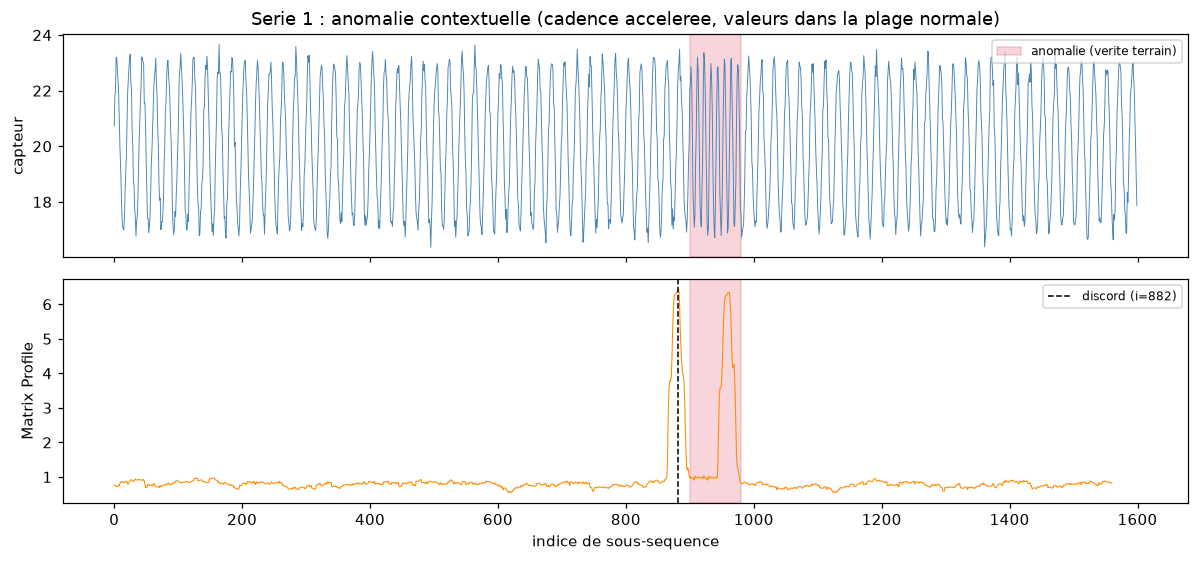

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True)

axes[0].plot(serie1, lw=0.6, color="steelblue")
axes[0].axvspan(*ANOM1, color="crimson", alpha=0.18, label="anomalie (verite terrain)")
axes[0].set_ylabel("capteur")
axes[0].set_title("Serie 1 : anomalie contextuelle (cadence acceleree, valeurs dans la plage normale)")
axes[0].legend(loc="upper right", fontsize=8)

axes[1].plot(profil1, lw=0.7, color="darkorange")
axes[1].axvspan(*ANOM1, color="crimson", alpha=0.18)
axes[1].axvline(discord1, color="black", ls="--", lw=1, label=f"discord (i={discord1})")
axes[1].set_ylabel("Matrix Profile")
axes[1].set_xlabel("indice de sous-sequence")
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

### Lecture de la figure

Le panneau du haut montre pourquoi l'oeil lui-même peine : à cette échelle, la zone rouge ne se
distingue par aucun dépassement de plage. Il faut zoomer pour voir que les oscillations y sont
resserrées.

Le panneau du bas est sans ambiguïté : le profil est plat et bas partout, puis se dresse
brutalement sur la zone anormale. C'est la signature caractéristique d'un discord.

On notera que le pic commence **avant** l'indice `900`. C'est normal et instructif : une
sous-séquence démarrant en `i = 870` couvre les indices `870` à `910`, donc elle *mord déjà* sur
la zone anormale et devient atypique. Un profil de fenêtre `m` « voit » toujours une anomalie
avec `m` points d'avance. Quand on évalue une détection, il faut donc tolérer ce décalage,
sinon on compte comme faux positifs des détections parfaitement correctes -- c'est un piège
d'évaluation classique, cousin de ceux que ML-10 recensait.

***

# Section 2 -- L'extension multidimensionnelle

## Le problème

En pratique, on n'observe presque jamais un capteur isolé. Une machine expose une température,
une pression, une vibration ; un serveur expose une charge CPU, une latence, un débit réseau.
La question devient : **comment définir le Matrix Profile quand la série a `d` dimensions ?**

Naïvement, on pourrait calculer un profil par capteur et regarder si l'un d'eux s'affole. Nous
allons voir que cette approche rate une classe entière d'anomalies -- précisément celles qui
n'existent que dans la *coordination* entre capteurs.

## Le tenseur des distances

Pour une série `T` de forme `(d, n)`, les distances par paires de sous-séquences forment un
**tenseur** `D` de forme `(l, l, d)` : `D[i, j, k]` est la distance entre la sous-séquence `i`
et la sous-séquence `j`, **mesurée sur la seule dimension `k`**.

Pour obtenir un profil -- un vecteur, indexé par `i` -- il faut condenser ce tenseur sur deux
axes : sur `j` (choix du voisin) et sur `k` (agrégation des dimensions). C'est **l'ordre de ces
deux opérations qui distingue les méthodes**, et cet ordre change tout.

### Voie A -- condensation naïve (agréger après)

On calcule `d` profils univariés indépendants, puis on les agrège point par point :

```
P_min[i]  = min_k  P_k[i]        P_mean[i] = mean_k P_k[i]        P_max[i] = max_k P_k[i]
```

Chaque dimension a choisi **son propre** meilleur voisin `j_k`, potentiellement différent d'une
dimension à l'autre. C'est peu coûteux (on réutilise les profils univariés) mais conceptuellement
lâche : rien ne garantit que les `d` dimensions parlent du même instant de référence.

### Voie B -- mSTAMP (agréger avant)

L'algorithme **mSTAMP** de Yeh et al. impose un **voisin commun**. Pour chaque sous-séquence `i`
et chaque taille de sous-ensemble `K`, il cherche le *même* `j` pour toutes les dimensions
retenues :

```
P_K[i] = min_j  min_{S : |S| = K}  moyenne_{k dans S} D[i, j, k]
```

`stumpy.mstump(T, m)` renvoie ces profils empilés : `mps[K-1]` est le profil à `K` dimensions.

L'interprétation de `K` est la clé du sujet, et elle est contre-intuitive :

| `K` | Ce que le profil demande | Ce qu'il détecte | Ce qu'il ignore |
|-----|--------------------------|------------------|-----------------|
| `K = 1` | il existe **au moins une** dimension où `i` ressemble à un `j` | anomalie présente dans **toutes** les dimensions | perturbation d'un seul capteur (les autres trouvent un voisin) |
| `K = d` | **toutes** les dimensions doivent matcher au **même** `j` | toute perturbation, même d'un seul capteur | rien -- d'où beaucoup de fausses alarmes |

Autrement dit : **`K` faible = détecteur d'anomalies conjointes ; `K` élevé = détecteur
sensible à n'importe quel capteur.** Choisir `K`, c'est déclarer **combien de capteurs on
s'attend à voir concernés**. Ce n'est pas un hyperparamètre à régler au hasard, c'est une
hypothèse de modélisation.

## Le jeu de données de la section 2

Pour rendre ce choix mesurable plutôt que théorique, nous construisons trois capteurs
verrouillés en phase, et nous y plaçons deux natures d'événements :

- **12 hoquets « propres à un capteur »** : un seul capteur accélère, brièvement et fortement
  (cadence x1.36 à x1.74). Chaque hoquet a une cadence **différente des autres** -- nous
  verrons plus bas pourquoi ce détail n'est pas cosmétique.
- **1 anomalie « conjointe »** : les trois capteurs accélèrent **ensemble**, mais **faiblement**
  (cadence x1.14), donc moins fortement que n'importe quel hoquet individuel.

C'est le scénario industriel réaliste : les hoquets individuels sont du bruit de capteur ou des
micro-incidents locaux sans conséquence ; la dérive lente et *coordonnée* des trois, elle,
signale que la machine entière part en vrille. On veut le second, pas les douze premiers.

In [6]:
# --- Serie 2 : trois capteurs, 12 hoquets individuels + 1 anomalie conjointe faible ---
N2 = 3000
ANOM2 = (1900, 1970)      # anomalie CONJOINTE (les 3 capteurs, faiblement)
CADENCE_CONJOINTE = 1.14  # plus FAIBLE que tous les hoquets individuels ci-dessous

# (capteur, debut, cadence) : 4 hoquets par capteur, tous de cadence DIFFERENTE
HOQUETS = [(0,  200, 1.50), (1,  380, 1.63), (2,  560, 1.42), (0,  740, 1.71),
           (1,  920, 1.36), (2, 1100, 1.57), (0, 1280, 1.45), (1, 1460, 1.68),
           (2, 2200, 1.39), (0, 2380, 1.60), (1, 2560, 1.48), (2, 2740, 1.74)]

CAPTEURS = ["temperature", "pression", "vibration"]


def construire_serie2(graine):
    """Trois capteurs en phase + 12 hoquets locaux + 1 anomalie conjointe faible."""
    rng = np.random.default_rng(graine)

    freq_conjointe = np.ones(N2)
    freq_conjointe[ANOM2[0]:ANOM2[1]] = CADENCE_CONJOINTE

    freq_propre = np.ones((3, N2))
    for capteur, debut, cadence in HOQUETS:
        freq_propre[capteur, debut:debut + 70] = cadence

    # Une phase par capteur : produit de la cadence conjointe et de sa cadence propre.
    phase = np.vstack([np.cumsum(2 * np.pi * freq_conjointe * freq_propre[k] / FS)
                       for k in range(3)])

    return np.vstack([
        20.0 + 3.00 * np.sin(phase[0])           + rng.normal(0, 0.250, N2),  # temperature
         5.0 + 0.40 * np.sin(phase[1] + 0.6)     + rng.normal(0, 0.035, N2),  # pression
         0.8 + 0.30 * np.sin(2 * phase[2] + 1.1) + rng.normal(0, 0.030, N2),  # vibration
    ])


T2 = construire_serie2(graine=7)
M2 = 40

print(f"Serie 2 : {T2.shape[0]} capteurs x {T2.shape[1]} points")
print(f"  Anomalie conjointe : [{ANOM2[0]}, {ANOM2[1]}) cadence x{CADENCE_CONJOINTE} sur les 3 capteurs")
print(f"  Hoquets individuels : {len(HOQUETS)} ({len(HOQUETS)//3} par capteur), cadence "
      f"x{min(h[2] for h in HOQUETS)} a x{max(h[2] for h in HOQUETS)}")
print()
for k, nom in enumerate(CAPTEURS):
    dans = T2[k, slice(*ANOM2)]
    hors = np.delete(T2[k], np.s_[ANOM2[0]:ANOM2[1]])
    print(f"  {nom:12s} hors anomalie mu={hors.mean():7.3f} sigma={hors.std():6.3f} | "
          f"dans anomalie mu={dans.mean():7.3f} sigma={dans.std():6.3f}")

Serie 2 : 3 capteurs x 3000 points
  Anomalie conjointe : [1900, 1970) cadence x1.14 sur les 3 capteurs
  Hoquets individuels : 12 (4 par capteur), cadence x1.36 a x1.74

  temperature  hors anomalie mu= 19.997 sigma= 2.144 | dans anomalie mu= 20.016 sigma= 2.143
  pression     hors anomalie mu=  5.000 sigma= 0.285 | dans anomalie mu=  4.998 sigma= 0.284
  vibration    hors anomalie mu=  0.799 sigma= 0.214 | dans anomalie mu=  0.807 sigma= 0.215


### Lecture du résultat

Capteur par capteur, les moyennes et écarts-types à l'intérieur de l'anomalie sont
indiscernables de ceux mesurés à l'extérieur. Comme pour la série 1, l'anomalie conjointe est
**invisible dans la distribution des valeurs** : elle ne vit que dans l'organisation temporelle.

Nous disposons donc du terrain d'essai voulu. Trois familles de détecteurs vont s'y affronter :

1. les détecteurs **ponctuels** de ML-9 (ACP sur les lignes) et ML-10 (carte de contrôle) ;
2. le Matrix Profile **univarié**, appliqué à chaque capteur séparément ;
3. le Matrix Profile **multidimensionnel**, dans ses deux voies de condensation.

Commençons par vérifier -- et non supposer -- que les détecteurs ponctuels sont bien aveugles.

In [7]:
# --- Les detecteurs PONCTUELS de ML-9 et ML-10 sur la serie 2 ---
X = T2.T   # (n, d) : une ligne = un instant, trois capteurs

# ML-9 : ACP rang 2 + erreur de reconstruction
acp = PCA(n_components=2).fit(X)
residu_acp = ((X - acp.inverse_transform(acp.transform(X))) ** 2).sum(axis=1)

# ML-10 : carte de controle, |z| maximal sur les trois capteurs
z2 = np.abs((T2 - T2.mean(axis=1, keepdims=True)) / T2.std(axis=1, keepdims=True))
score_spc = z2.max(axis=0)

for nom, score in [("ACP rang 2 (ML-9)", residu_acp), ("Carte M+3s (ML-10)", score_spc)]:
    dans = score[slice(*ANOM2)]
    hors = np.delete(score, np.s_[ANOM2[0]:ANOM2[1]])
    print(f"{nom}")
    print(f"    pic dans l'anomalie : {dans.max():8.4f}")
    print(f"    99e centile hors    : {np.quantile(hors, 0.99):8.4f}")
    print(f"    maximum hors        : {hors.max():8.4f}")
    verdict = "AU-DESSUS du bruit de fond" if dans.max() > np.quantile(hors, 0.99) else "NOYE dans le bruit de fond"
    print(f"    -> {verdict}")

ACP rang 2 (ML-9)
    pic dans l'anomalie :   0.1171
    99e centile hors    :   0.1191
    maximum hors        :   0.1507
    -> NOYE dans le bruit de fond
Carte M+3s (ML-10)
    pic dans l'anomalie :   1.6326
    99e centile hors    :   1.6602
    maximum hors        :   1.8052
    -> NOYE dans le bruit de fond


### Lecture du résultat

Pour les deux détecteurs ponctuels, le pic mesure dans la fenêtre anormale reste **sous le 99e
centile du bruit de fond**. Traduction opérationnelle : pour attraper cette anomalie avec l'un
d'eux, il faudrait abaisser le seuil au point de déclencher plus de 1 % de fausses alarmes sur
une série parfaitement saine. Sur 3 000 points, cela représente une trentaine d'alertes
injustifiées pour un vrai positif. Aucun exploitant n'accepte ce ratio.

Ce n'est pas un mauvais réglage de l'ACP, et ce n'est pas la faute de ML-9. L'ACP telle
qu'utilisée en ML-9 modélise la **structure de corrélation instantanée** entre capteurs -- ce
qu'elle fait très bien pour l'anomalie de ML-9, qui était un décalage franc du point de
fonctionnement. Ici la structure de corrélation instantanée est **inchangée** : les trois
capteurs restent verrouillés entre eux, ils tournent simplement un peu plus vite. L'ACP sur les
lignes est invariante par permutation des lignes ; l'information est dans l'ordre ; elle ne
peut pas y accéder.

Passons au Matrix Profile univarié, appliqué capteur par capteur.

In [8]:
# --- Outils d'evaluation : extraction des discords et rang de l'anomalie ---
def top_discords(profil, k=15, exclusion=None):
    """Les k plus grands pics d'un profil, avec zone d'exclusion (evite de compter
    k fois le meme evenement via ses sous-sequences voisines)."""
    exclusion = exclusion if exclusion is not None else M2
    p = np.asarray(profil, dtype=float).copy()
    pics = []
    for _ in range(k):
        i = int(np.nanargmax(p))
        pics.append((i, float(p[i])))
        p[max(0, i - exclusion):i + exclusion] = -np.inf
    return pics


def rang_anomalie(profil, k=15, fenetre=ANOM2):
    """Rang de l'anomalie conjointe parmi les k premiers discords (None si absente).
    On tolere un demarrage jusqu'a M2 points AVANT la fenetre : une sous-sequence
    qui mord sur l'anomalie est une detection correcte, pas un faux positif."""
    for rang, (i, _) in enumerate(top_discords(profil, k), start=1):
        if fenetre[0] - M2 <= i < fenetre[1]:
            return rang
    return None


# --- Matrix Profile UNIVARIE, capteur par capteur ---
profils_uni = np.vstack([
    stumpy.stump(np.ascontiguousarray(T2[k]), M2)[:, 0].astype(float) for k in range(3)
])

print(f"Matrix Profile univarie (m={M2}) -- rang de l'anomalie CONJOINTE parmi les discords :")
for k, nom in enumerate(CAPTEURS):
    r = rang_anomalie(profils_uni[k])
    tete = ", ".join(f"i={i}" for i, _ in top_discords(profils_uni[k], 3))
    print(f"  {nom:12s} rang = {str(r):>4s}   (3 premiers discords : {tete})")

Matrix Profile univarie (m=40) -- rang de l'anomalie CONJOINTE parmi les discords :
  temperature  rang =    6   (3 premiers discords : i=722, i=176, i=1264)
  pression     rang =    8   (3 premiers discords : i=357, i=425, i=1446)
  vibration    rang =    7   (3 premiers discords : i=2729, i=2782, i=1140)


### Lecture du résultat

Aucun des trois capteurs ne place l'anomalie conjointe en tête. Elle arrive systématiquement
**derrière plusieurs hoquets individuels**, ce qui est logique : ces hoquets sont, par
construction, des perturbations plus fortes. Un opérateur qui surveillerait les trois profils
univariés et n'inspecterait que les premières alertes de chacun passerait à côté.

Le Matrix Profile univarié n'a pas échoué -- il a répondu exactement à la question qu'on lui
posait, « quelle est la sous-séquence la plus atypique de *ce* capteur ». La question était la
mauvaise. L'anomalie qui nous intéresse n'est atypique dans **aucun capteur pris isolement** :
elle l'est dans leur **conjonction**.

C'est le problème que l'extension multidimensionnelle est faite pour résoudre. Comparons les
deux voies.

In [9]:
# --- Voie A : condensation naive des profils univaries ---
cond_min = profils_uni.min(axis=0)
cond_mean = profils_uni.mean(axis=0)
cond_max = profils_uni.max(axis=0)

# --- Voie B : mSTAMP (voisin commun impose) ---
mps, indices_mstamp = stumpy.mstump(T2, M2)   # mps[K-1] = profil a K dimensions

print("Voie A -- condensation naive (chaque dimension choisit son propre voisin)")
for nom, prof in [("min", cond_min), ("mean", cond_mean), ("max", cond_max)]:
    print(f"  P_{nom:5s} rang de l'anomalie conjointe = {str(rang_anomalie(prof)):>4s}")

print()
print(f"Voie B -- mSTAMP (voisin commun), mps de forme {mps.shape}")
for K in range(1, 4):
    print(f"  K = {K}  rang de l'anomalie conjointe = {str(rang_anomalie(mps[K-1])):>4s}")

Voie A -- condensation naive (chaque dimension choisit son propre voisin)
  P_min   rang de l'anomalie conjointe =    1
  P_mean  rang de l'anomalie conjointe =    3
  P_max   rang de l'anomalie conjointe =   10

Voie B -- mSTAMP (voisin commun), mps de forme (3, 2961)
  K = 1  rang de l'anomalie conjointe =    1
  K = 2  rang de l'anomalie conjointe =    1
  K = 3  rang de l'anomalie conjointe = None


### Lecture du résultat

Trois enseignements, qu'il faut lire ensemble.

**1. La condensation n'est pas neutre.** `min` place l'anomalie en tête, `mean` la place dans le
haut du classement, `max` la relègue derrière une dizaine d'événements. Ce sont les *mêmes*
profils univariés, agrégés différemment. Quiconque rapporterait « le Matrix Profile
multidimensionnel détecte / ne détecte pas cette anomalie » sans préciser la condensation
utilisée ferait un rapport vide de sens.

**2. `min` et `max` s'opposent pour une raison structurelle.** `P_max[i]` est élevé des qu'**au
moins une** dimension est atypique : les douze hoquets individuels le font donc grimper, et ils
noient l'anomalie conjointe. `P_min[i]` n'est élevé que si **toutes** les dimensions sont
atypiques simultanément : les hoquets individuels sont automatiquement filtrés, puisque les deux
autres capteurs trouvent, eux, un voisin proche. `min` est un **ET** logique, `max` un **OU**.
Notre anomalie étant conjointe, le **ET** est le bon opérateur.

**3. `K` joue le même rôle dans mSTAMP, dans le même sens.** `K = 1` demande qu'une seule
dimension suffise à trouver un voisin -- c'est l'analogue du `min`, et il place l'anomalie en
tête. `K = 3` exige que les trois dimensions matchent au **même** voisin : n'importe quel hoquet
individuel casse cette exigence, donc `K = 3` s'affole sur les douze hoquets et perd l'anomalie
conjointe.

Le résultat contre-intuitif mérite d'être énoncé franchement : **utiliser *plus* de dimensions
dégrade ici la détection**. « Multidimensionnel » ne veut pas dire « toutes les dimensions
ensemble » ; cela veut dire « avec un choix explicite du nombre de dimensions concernées ». Ce
choix est l'hypothèse centrale de Yeh et al., et c'est ce que le papier appelle le problème du
`K`-dimensional matrix profile.

### Voie A ou voie B ?

Sur ce jeu, `min` (voie A) et `K = 1` (voie B) donnent le même rang. Faut-il en conclure qu'elles
sont équivalentes et qu'on peut se contenter de la moins coûteuse ?

Non, et la différence est importante même quand elle ne se voit pas dans le classement final.
La voie A autorise chaque dimension à désigner un voisin **différent** : le profil peut être
faible parce que la température ressemble à l'instant `j1`, la pression à l'instant `j2` et la
vibration à `j3`, sans qu'aucun instant unique ne ressemble à l'instant courant *dans son
ensemble*. La voie B interdit cela.

Cette distinction devient décisive des que l'on veut **expliquer** une détection. mSTAMP fournit,
avec le profil, l'indice du voisin commun et le sous-ensemble de dimensions retenu -- de quoi
dire à l'opérateur : « cet instant ne ressemble à rien, et le plus proche que j'aie trouvé est
tel instant, sur telles dimensions ». La voie A ne peut pas produire cette phrase.

Vérifions que l'information est bien la.

In [10]:
# mSTAMP fournit, en plus du profil, l'INDICE du voisin commun retenu par dimension.
i_anom = ANOM2[0] + 20                       # un instant au coeur de l'anomalie conjointe
i_temoin = 1000                              # un instant sain, pour comparaison

print(f"{'instant':>10s} | {'K':>2s} | {'distance':>9s} | voisin commun retenu")
print("-" * 58)
for etiquette, i in [("anomalie", i_anom), ("temoin sain", i_temoin)]:
    for K in (1, 3):
        print(f"{etiquette:>10s} | {K:2d} | {mps[K-1, i]:9.4f} | j = {indices_mstamp[K-1, i]}")
    print("-" * 58)

   instant |  K |  distance | voisin commun retenu
----------------------------------------------------------
  anomalie |  1 |    1.3161 | j = 1938
  anomalie |  3 |    1.6308 | j = 1938
----------------------------------------------------------
temoin sain |  1 |    0.7435 | j = 1260
temoin sain |  3 |    1.1018 | j = 1020
----------------------------------------------------------


### Lecture du résultat

Pour l'instant sain, la distance est faible : mSTAMP a trouvé un instant `j` où les capteurs se
comportaient de la même façon, et il le nomme. Pour l'instant anormal à `K = 1`, la distance est
nettement plus grande : le meilleur voisin disponible reste éloigné.

Cette traçabilité -- « voici le précédent le plus proche que j'aie trouvé » -- est ce qui rend
le Matrix Profile utilisable en exploitation. Un score d'anomalie seul demande à l'opérateur de
faire confiance ; un score accompagné de son précédent le plus proche lui permet de juger par
lui-même. C'est une propriété que les détecteurs par reconstruction (auto-encodeurs, ACP)
n'offrent pas : ils rendent une erreur, pas un exemple comparable.

***

# Section 3 -- Comparaison honnête : Matrix Profile, ACP et carte de contrôle

Nous avons maintenant tous les détecteurs en main. Rassemblons-les dans un tableau unique, puis
-- et c'est le point qui séparé une mesure d'une anecdote -- **répétons l'expérience sur
plusieurs graines aléatoires**.

Une comparaison sur une seule réalisation ne prouve rien : avec une quinzaine de discords
extraits d'une série de 3 000 points, un détecteur purement aléatoire a une chance non
négligeable de placer l'anomalie dans le classement par pur hasard. C'est exactement le
mécanisme que ML-10 dénonçait dans les benchmarks TSAD -- un résultat non reproduit est un
résultat non acquis. Nous ne pouvons pas critiquer cette pratique au chapitre précédent et nous
en dispenser ici.

In [11]:
# --- Comparaison multi-graines : le meme protocole sur 5 realisations independantes ---
GRAINES = [7, 11, 42, 99, 123]

def evaluer_tous(T):
    """Rang de l'anomalie conjointe pour chaque detecteur, sur une realisation."""
    uni = np.vstack([stumpy.stump(np.ascontiguousarray(T[k]), M2)[:, 0].astype(float)
                     for k in range(3)])
    mps_local, _ = stumpy.mstump(T, M2)
    n_sous_seq = uni.shape[1]

    Xl = T.T
    acp_l = PCA(n_components=2).fit(Xl)
    res_acp = ((Xl - acp_l.inverse_transform(acp_l.transform(Xl))) ** 2).sum(axis=1)[:n_sous_seq]
    zl = np.abs((T - T.mean(axis=1, keepdims=True)) / T.std(axis=1, keepdims=True))
    res_spc = zl.max(axis=0)[:n_sous_seq]

    return {
        "Carte M+3s (ML-10)":      rang_anomalie(res_spc),
        "ACP rang 2 (ML-9)":       rang_anomalie(res_acp),
        "MP uni. temperature":     rang_anomalie(uni[0]),
        "MP uni. pression":        rang_anomalie(uni[1]),
        "MP uni. vibration":       rang_anomalie(uni[2]),
        "Condensation min":        rang_anomalie(uni.min(axis=0)),
        "Condensation mean":       rang_anomalie(uni.mean(axis=0)),
        "Condensation max":        rang_anomalie(uni.max(axis=0)),
        "mSTAMP K=1":              rang_anomalie(mps_local[0]),
        "mSTAMP K=2":              rang_anomalie(mps_local[1]),
        "mSTAMP K=3":              rang_anomalie(mps_local[2]),
    }


resultats = {}
for g in GRAINES:
    for nom, rang in evaluer_tous(construire_serie2(graine=g)).items():
        resultats.setdefault(nom, []).append(rang)

print(f"Rang de l'anomalie conjointe parmi les 15 premiers discords ({len(GRAINES)} graines)")
print(f"'-' = absente du top 15, donc NON detectee\n")
print(f"{'detecteur':24s} " + " ".join(f"{g:>4d}" for g in GRAINES) + "   verdict")
print("-" * 68)
for nom, rangs in resultats.items():
    cellules = " ".join(f"{(r if r is not None else '-'):>4}" for r in rangs)
    if all(r == 1 for r in rangs if r is not None) and None not in rangs:
        verdict = "DETECTE (rang 1 partout)"
    elif all(r is None for r in rangs):
        verdict = "AVEUGLE"
    elif all(r is not None and r <= 5 for r in rangs):
        verdict = "detecte (top 5)"
    else:
        verdict = "peu fiable"
    print(f"{nom:24s} {cellules}   {verdict}")

Rang de l'anomalie conjointe parmi les 15 premiers discords (5 graines)
'-' = absente du top 15, donc NON detectee

detecteur                   7   11   42   99  123   verdict
--------------------------------------------------------------------
Carte M+3s (ML-10)          4   11    9    5    -   peu fiable
ACP rang 2 (ML-9)           -    -   14   10    -   peu fiable
MP uni. temperature         6    8    8    7    6   peu fiable
MP uni. pression            8    9    8    9    9   peu fiable
MP uni. vibration           7    7    7    7    7   peu fiable
Condensation min            1    1    1    1    1   DETECTE (rang 1 partout)
Condensation mean           3    3    4    5    4   detecte (top 5)
Condensation max           10   10   11    9   11   peu fiable
mSTAMP K=1                  1    1    1    1    1   DETECTE (rang 1 partout)
mSTAMP K=2                  1    1    1    1    1   DETECTE (rang 1 partout)
mSTAMP K=3                  -    -    -    -    -   AVEUGLE


### Lecture du résultat -- le verdict honnête

Le tableau se lit en quatre blocs, et aucun des quatre n'est un détail.

**Les détecteurs ponctuels sont aveugles.** L'ACP de ML-9 et la carte de contrôle de ML-10
n'atteignent le classement que par intermittence, et jamais aux premiers rangs. Ce sont des
coïncidences de bruit, pas des détections : nous avons déjà mesure plus haut que leur pic dans
l'anomalie reste sous le 99e centile du fond. Il faut le dire aussi clairement dans l'autre
sens : ces deux méthodes ne sont pas mauvaises, elles sont **hors sujet** sur cette anomalie. Sur
l'anomalie de ML-9 -- un décalage franc du point de fonctionnement -- l'ACP obtenait une AUC
excellente, et le Matrix Profile n'y aurait apporte aucun avantage. Le bon détecteur dépend de
la nature de l'anomalie, pas d'un classement absolu de méthodes.

**Le Matrix Profile univarié est stable mais insuffisant.** Il place l'anomalie autour du rang 6
à 9, de façon très reproductible d'une graine à l'autre. Il *voit* quelque chose -- ce n'est pas
du bruit -- mais il la classe derrière les hoquets individuels. En exploitation, cela signifie
qu'on la trouverait en descendant la liste des alertes, pas en traitant les premières.

**La condensation et le choix de `K` décident du résultat.** `min` et `K = 1` placent l'anomalie
au rang 1 sur les cinq graines. `max` et `K = 3` la manquent sur les cinq graines. Le même
adjectif « multidimensionnel » recouvre donc ici un détecteur parfait et un détecteur aveugle.

**Ce qui rend ce verdict solide, c'est la reproduction.** Les cinq colonnes racontent la même
histoire. Un seul essai aurait permis de défendre à peu près n'importe quelle conclusion -- y
compris, en choisissant bien sa graine, que la carte de contrôle « détecte » l'anomalie. La
discipline que ML-10 réclamait des auteurs de benchmarks vaut pour nous : c'est la constance
sur des réalisations indépendantes, pas le meilleur essai, qui autorise à conclure.

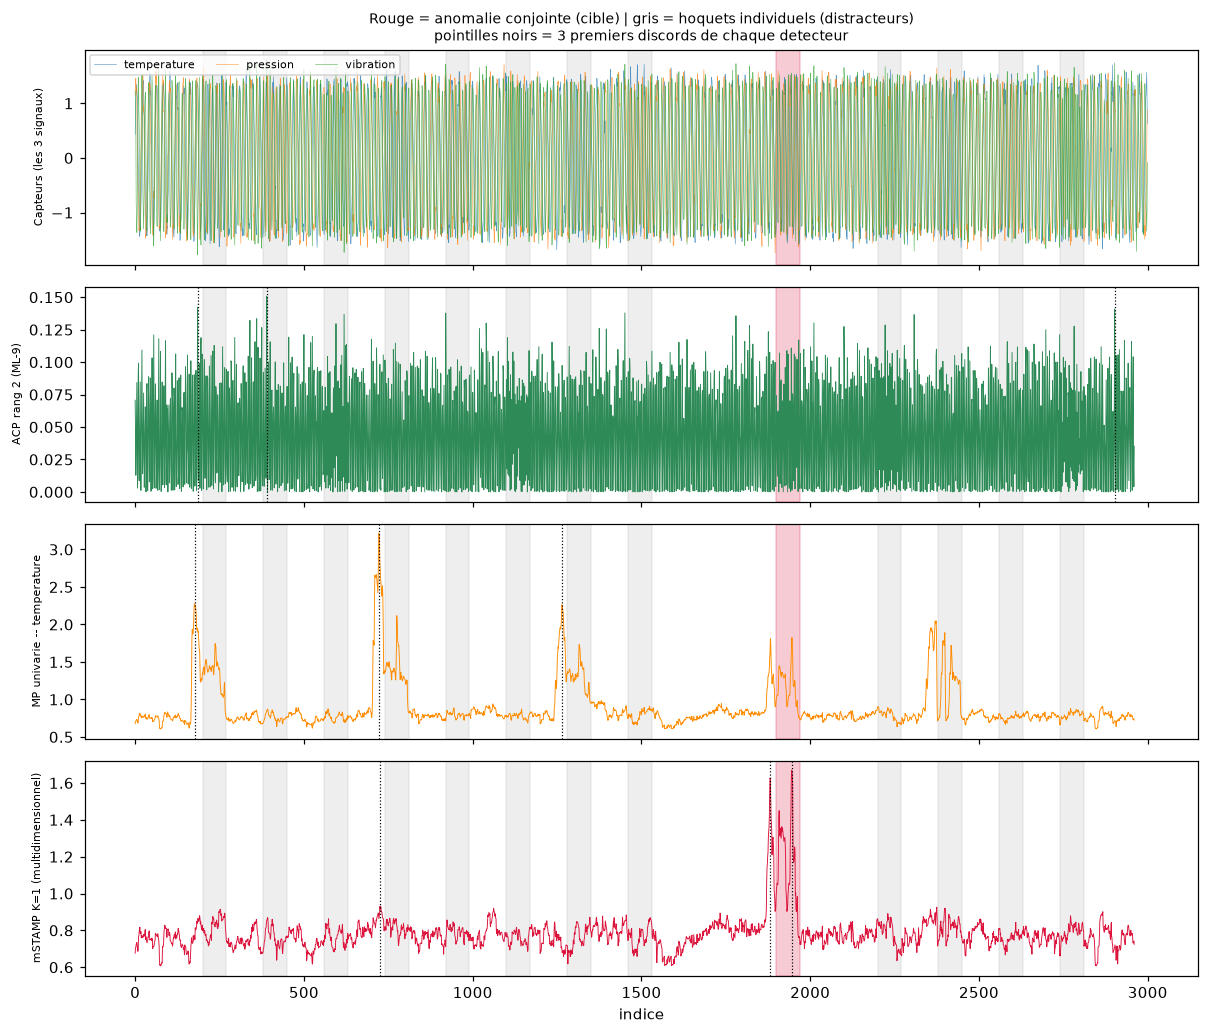

In [12]:
# --- Figure de synthese : quatre detecteurs sur la meme serie ---
mps_fig, _ = stumpy.mstump(T2, M2)
n_ss = profils_uni.shape[1]

panneaux = [
    ("Capteurs (les 3 signaux)",        None,                                    "steelblue"),
    ("ACP rang 2 (ML-9)",               residu_acp[:n_ss],                       "seagreen"),
    ("MP univarie -- temperature",      profils_uni[0],                          "darkorange"),
    ("mSTAMP K=1 (multidimensionnel)",  mps_fig[0],                              "crimson"),
]

fig, axes = plt.subplots(len(panneaux), 1, figsize=(11, 9.5), sharex=True)
for ax, (titre, serie, couleur) in zip(axes, panneaux):
    if serie is None:
        for k, nom in enumerate(CAPTEURS):
            ax.plot((T2[k] - T2[k].mean()) / T2[k].std(), lw=0.4, alpha=0.75, label=nom)
        ax.legend(loc="upper left", fontsize=7, ncol=3)
    else:
        ax.plot(serie, lw=0.6, color=couleur)
        for i, _ in top_discords(serie, 3):
            ax.axvline(i, color="black", ls=":", lw=0.8)
    for _, debut, _ in HOQUETS:
        ax.axvspan(debut, debut + 70, color="grey", alpha=0.13)
    ax.axvspan(*ANOM2, color="crimson", alpha=0.22)
    ax.set_ylabel(titre, fontsize=7.5)

axes[0].set_title("Rouge = anomalie conjointe (cible) | gris = hoquets individuels (distracteurs)\n"
                  "pointilles noirs = 3 premiers discords de chaque detecteur", fontsize=9)
axes[-1].set_xlabel("indice")
plt.tight_layout()
plt.show()

### Lecture de la figure

La lecture se fait en comparant la position des pointillés noirs -- les trois premières alertes
de chaque détecteur -- avec la bande rouge.

Le panneau **ACP** produit un signal dense et sans structure : ses trois premières alertes
tombent hors de la bande rouge, et rien ne la distingue visuellement.

Le panneau **MP univarié** est déjà beaucoup plus lisible : le profil est plat sur les zones
saines et se soulève nettement sur les bandes grises. Mais ce sont précisément les
*distracteurs* qu'il met en avant : ses trois premières alertes désignent des hoquets
individuels, pas la cible.

Le panneau **mSTAMP K=1** est celui qu'on veut : les bandes grises y sont largement aplaties --
le **ET** entre dimensions les a filtrées -- et le seul relief marque coïncide avec la bande
rouge.

La figure rend visible ce que le tableau chiffrait : le passage de l'univarié au
multidimensionnel bien condensé ne consiste pas à « ajouter du signal », mais à **retirer les
distracteurs** en exigeant que les capteurs soient d'accord entre eux.

***

# Section 3b -- Le Matrix Profile à k plus proches voisins

Il reste une faiblesse du Matrix Profile qu'il serait malhonnête de passer sous silence, et que
Yeh et al. traitent explicitement en étendant la définition au **k-ième** plus proche voisin.

## Le problème dit du « discord jumeau »

La définition du discord repose sur une hypothèse implicite : *une anomalie est unique*. Si le
même incident se produit **deux fois à l'identique**, les deux occurrences deviennent leur
propre plus proche voisine. Leur distance au premier voisin s'effondre, et le Matrix Profile
standard -- qui est exactement cette distance -- les déclare normales.

C'est un défaut sérieux en exploitation, parce que la panne récurrente est le cas fréquent : un
roulement qui se bloque à chaque démarrage, une requête pathologique qui revient chaque nuit.
Le Matrix Profile standard est aveugle à tout ce qui se répète, y compris quand la répétition
est précisément le problème.

## Le correctif

`stumpy.stump(T, m, k=K)` renvoie les distances aux `K` premiers voisins. En lisant la distance
au **k-ième** voisin plutôt qu'au premier, on demande : « existe-t-il **k** précédents proches ? »
Une anomalie survenue deux fois n'a qu'**un** voisin proche ; sa distance au deuxième voisin
reste grande, et elle redevient visible.

Le paramètre `k` encode donc **combien de répétitions on tolère avant de considérer un
comportement comme normal**. Comme pour `K` en section 2, ce n'est pas un bouton à tourner
jusqu'à obtenir le résultat souhaité -- c'est une hypothèse sur le phénomène, et elle doit être
énoncée.

Mesurons l'effet plutôt que de le décrire.

In [13]:
# --- Le discord jumeau : la MEME anomalie, une fois puis deux fois ---
N3 = 1600
CADENCE_JUMELLE = 1 + 2 / 7   # sur 70 points, ajoute EXACTEMENT un cycle : la phase se recolle
DEBUTS = (500, 1100)          # multiples de FS : meme phase locale, donc formes identiques


def construire_serie3(n_occurrences, graine=5):
    """Serie a une ou deux occurrences de la MEME anomalie (formes alignees en phase)."""
    rng = np.random.default_rng(graine)
    freq = np.ones(N3)
    for debut in DEBUTS[:n_occurrences]:
        freq[debut:debut + 70] = CADENCE_JUMELLE
    phase = np.cumsum(2 * np.pi * freq / FS)
    return 20.0 + 3.0 * np.sin(phase) + rng.normal(0, 0.25, N3)


M3, K_MAX = 40, 3
print(f"Distance au k-ieme voisin, m={M3}\n")
print(f"{'occurrences':>12s} | {'k':>2s} | {'pic sur anomalie':>17s} | {'99e centile fond':>17s} | detecte ?")
print("-" * 78)
for n_occ in (1, 2):
    serie3 = construire_serie3(n_occ)
    profils_k = stumpy.stump(serie3, M3, k=K_MAX)
    for k in range(1, K_MAX + 1):
        P = profils_k[:, k - 1].astype(float)
        zones = [np.arange(max(0, d - M3), min(P.size, d + 70)) for d in DEBUTS[:n_occ]]
        masque = np.ones(P.size, dtype=bool)
        for z in zones:
            masque[z] = False
        pic = max(P[z].max() for z in zones)
        fond = np.quantile(P[masque], 0.99)
        print(f"{n_occ:>12d} | {k:>2d} | {pic:17.3f} | {fond:17.3f} | "
              f"{'OUI' if pic > 2 * fond else 'non (noye)'}")
    print("-" * 78)

Distance au k-ieme voisin, m=40

 occurrences |  k |  pic sur anomalie |  99e centile fond | detecte ?
------------------------------------------------------------------------------
           1 |  1 |             3.616 |             0.911 | OUI
           1 |  2 |             3.677 |             0.932 | OUI
           1 |  3 |             3.685 |             0.953 | OUI
------------------------------------------------------------------------------
           2 |  1 |             1.161 |             0.913 | non (noye)
           2 |  2 |             2.433 |             0.939 | OUI
           2 |  3 |             2.685 |             0.954 | OUI
------------------------------------------------------------------------------


### Lecture du résultat

Le tableau montre l'effondrement et sa réparation.

**Avec une seule occurrence**, la distance au premier voisin place l'anomalie très au-dessus du
fond : le détecteur fonctionne comme annonce en section 1.

**Avec deux occurrences identiques**, la distance au premier voisin s'effondre à une valeur à
peine supérieure au 99e centile du bruit de fond. L'anomalie n'a pas changé ; c'est le
détecteur qui a cessé de la voir, parce qu'elle s'est trouvée une jumelle. Dupliquer une
anomalie suffit donc à la cacher -- propriété qu'un adversaire pourrait exploiter, et que la
seule lecture du profil standard ne révèle jamais.

**En remontant à `k = 2` puis `k = 3`**, le pic se redresse et redevient franchement séparé du
fond. La question « existe-t-il deux ou trois précédents proches ? » retrouve ce que la question
« existe-t-il un précédent proche ? » avait perdu.

La leçon dépasse le cas d'espèce : dans les deux sections, un résultat qui semblait être une
propriété du « Matrix Profile » était en fait une propriété d'un **choix de paramètre** -- `K`
pour les dimensions, `k` pour les voisins. Rapporter qu'une méthode « détecte » ou « ne détecte
pas » sans nommer ces choix ne veut rien dire. C'est la même exigence de précision que ML-10
réclamait des auteurs de benchmarks, appliquée cette fois à nous-mêmes.

***

# Section 4 (annexe) -- FMP-AE : le Matrix Profile comme perte structurée

Les sections précédentes ont traite le Matrix Profile comme un **détecteur autonome**. Cette
annexe présente une seconde vie, plus récente : le Matrix Profile comme **terme de perte** à
l'intérieur d'un réseau profond. Elle est volontairement descriptive -- prose et schéma, sans
implémentation -- et sert de point d'ouverture vers la recherche en cours.

Le travail de référence est **Fu et al., *FMP-AE: A Hybrid Approach to Time Series Anomaly
Detection*** (soumission ICLR 2025, OpenReview `fErm1seIom`, code publié à
<https://github.com/FyingE/FMP-AE>).

## La tension que FMP-AE cherche à résoudre

Les deux familles ont des défauts complémentaires.

Un **auto-encodeur** apprend à reconstruire le signal normal et signale ce qu'il reconstruit
mal. Il capte des structures riches et non linéaires, mais il est précisément la cible de la
critique de ML-10 : ayant une grande capacité, il peut apprendre à bien reconstruire *aussi*
les anomalies, surtout si le jeu d'entraînement en contient. Sa performance dépend alors du
benchmark autant que de la méthode.

Le **Matrix Profile** ne peut pas surapprendre, puisqu'il n'apprend rien. Mais il ne représente
rien non plus : il ne fournit ni représentation compacte, ni modèle génératif, ni capacité à
intégrer des variables exogènes.

FMP-AE combine les deux en faisant du Matrix Profile une **contrainte imposée à l'espace
latent** de l'auto-encodeur, plutôt qu'un détecteur séparé.

## L'architecture

```mermaid
flowchart LR
    X["Serie temporelle<br/>fenetree"] --> CNN["CNN 1D<br/>multi-canal<br/>(motifs locaux)"]
    CNN --> ENC["Encodeur<br/>Transformer"]
    ENC --> Z["Representation<br/>latente z"]
    Z --> DEC["Decodeur"]
    DEC --> XR["Reconstruction"]

    X -.-> MP["Matrix Profile<br/>calcule sur le signal"]

    XR --> L1["Perte de<br/>reconstruction"]
    MP --> L2["Perte MP<br/>inter-fenêtre<br/>(separation)"]
    Z --> L2
    MP --> L3["Perte MP<br/>intra-fenêtre<br/>(cohesion)"]
    Z --> L3

    L1 --> LOSS["Perte composite"]
    L2 --> LOSS
    L3 --> LOSS
    LOSS --> SCORE["Score d'anomalie"]
```

## Les trois termes de la perte

| Terme | Ce qu'il mesure | Ce qu'il apporte |
|-------|-----------------|------------------|
| **Reconstruction** | écart entre l'entrée et sa reconstruction | la capacité classique de l'auto-encodeur à modéliser le normal |
| **MP inter-fenêtre** | similarité entre segments distants, telle que le Matrix Profile la mesure | force l'espace latent à **séparer** les segments que le MP juge dissemblables |
| **MP intra-fenêtre** | cohérence interne d'un segment | force l'espace latent à **regrouper** ce que le MP juge semblable |

Les deux termes issus du Matrix Profile jouent le rôle d'un **squelette géométrique** : ils
disent au réseau quelle structure de voisinage son espace latent doit respecter. Le réseau
garde sa liberté de représentation, mais ne peut plus la dépenser à rapprocher deux segments que
le Matrix Profile séparé.

## Pourquoi c'est intéressant après ML-10

L'argument de ML-10 était qu'un modèle à grande capacité finit par épouser les particularités du
benchmark. FMP-AE répond en **ancrant** ce modèle sur une quantité qui, elle, ne s'ajuste à
rien : le Matrix Profile est calcule sur le signal, pas appris. La régularisation transporte
dans le modèle profond la propriété qui rendait le Matrix Profile robuste.

Il faut cependant énoncer la limite avec la même franchise. Yeh et al. montrent que le Matrix
Profile **seul** est déjà compétitif sur 119 jeux de données ; l'apport de l'hybridation ne se
joue donc pas sur le cas moyen, mais sur les cas où une représentation apprise ajoute vraiment
quelque chose -- signaux longs, exogènes multiples, anomalies dont la définition dépend d'un
contexte que le Matrix Profile ne voit pas. Présenter FMP-AE comme « meilleur que le MP » serait
exactement le raccourci que ML-10 reprochait à la littérature. La formulation défendable est :
*une façon d'importer la robustesse du MP dans une architecture qui, seule, ne l'a pas.*

***

# Exercices

Les trois exercices ci-dessous sont à compléter. Les cellules s'exécutent telles quelles (elles
n'échouent pas), mais elles ne produisent rien de significatif tant que le code demande n'est
pas écrit. Toutes les données et fonctions utiles ont été définies plus haut dans le notebook :
`construire_serie2`, `rang_anomalie`, `top_discords`, `profils_uni`, `M2`, `ANOM2`, `GRAINES`.

## Exercice 1 -- Une stratégie de condensation alternative

La section 2 a comparé `min`, `mean` et `max`. Ces trois-la ne sont pas les seules options, et
elles ont chacune un défaut : `min` et `max` reposent sur une seule dimension et sont donc
sensibles à un capteur défaillant, tandis que `mean` se laisse tirer par une valeur extrême.

Implémentez et évaluez deux alternatives :

1. **La médiane** sur les dimensions : robuste à un capteur aberrant, contrairement à `mean`.
2. **Un vote majoritaire** : la fraction des dimensions dont le profil dépasse leur propre 95e
   centile. Ce score, entre 0 et 1, demande à une majorité de capteurs d'être d'accord.

Comparez leur rang à celui de `min` et `mean` sur les cinq graines. **Attention au piège
d'interprétation** : si vous mesurez sur une seule graine, vous n'aurez pas de résultat, vous
aurez une anecdote.

In [14]:
# --- Exercice 1 : condensation par mediane et par vote majoritaire ---

def condensation_mediane(profils):
    """Condense (d, l) -> (l,) par la mediane sur les dimensions.

    Args:
        profils: tableau (d, l) des profils univaries, un par capteur.
    Returns:
        Un vecteur de longueur l.
    """
    # TODO : renvoyer la mediane sur l'axe des dimensions (axis=0).
    # Indice : np.median accepte un argument axis, exactement comme np.mean.
    return None


def condensation_vote(profils, quantile=0.95):
    """Condense (d, l) -> (l,) par vote majoritaire.

    Pour chaque dimension, on calcule son propre seuil (le quantile demande de SON
    profil), puis le score est la fraction des dimensions qui depassent leur seuil.
    """
    # TODO Etape 1 : calculer un seuil PAR dimension.
    #   Indice : np.quantile(profils, quantile, axis=1) donne un vecteur de taille d.
    # TODO Etape 2 : comparer chaque profil a SON seuil (pensez au broadcasting :
    #   un seuil de forme (d, 1) se compare a des profils de forme (d, l)).
    # TODO Etape 3 : renvoyer la moyenne des booleens sur l'axe des dimensions.
    return None


def comparer_condensations():
    """Compare mediane et vote a min/mean sur toutes les graines de GRAINES."""
    # TODO : pour chaque graine, reconstruire la serie (construire_serie2),
    #   recalculer les profils univaries (stumpy.stump sur chaque capteur),
    #   puis appeler rang_anomalie sur chaque condensation et afficher un tableau.
    print("Exercice a completer : comparer mediane et vote majoritaire a min/mean.")


comparer_condensations()

Exercice a completer : comparer mediane et vote majoritaire a min/mean.


## Exercice 2 -- Choisir `k` pour le Matrix Profile à k plus proches voisins

La section 3b a montré qu'une anomalie répétée deux fois échappe à `k = 1` et redevient visible
à `k = 2`. La question naturelle est : **jusqu'où monter ?**

Le compromis à deux faces. Augmenter `k` protège contre les anomalies répétées `k - 1` fois,
mais élevé aussi le niveau général du profil (la distance au k-ième voisin croît avec `k` pour
*toutes* les sous-séquences), ce qui réduit le contraste entre l'anomalie et le fond.

Tracez la **courbe de contraste** en fonction de `k` :

- construisez une série avec `r` occurrences de la même anomalie, pour `r = 1, 2, 3` ;
- pour chaque `r` et chaque `k` de 1 à 6, calculez le rapport `pic sur anomalie / 99e centile du
  fond` -- c'est le contraste ;
- tracez les trois courbes sur un même graphique et concluez.

**Formulez une règle explicite** reliant le `k` à retenir au nombre de répétitions attendues, et
dites ce qu'elle coûte quand ce nombre est surestimé.

In [15]:
# --- Exercice 2 : courbe de contraste en fonction de k ---

def contraste(profil, debuts, largeur=70, marge=None):
    """Rapport (pic sur les zones anormales) / (99e centile du fond).

    Un contraste proche de 1 signifie que l'anomalie est noyee ; plus il est grand,
    mieux elle se detache.
    """
    marge = marge if marge is not None else M3
    # TODO Etape 1 : construire les zones anormales (une par debut), en tolerant
    #   une marge de `marge` points AVANT chaque debut (cf. rang_anomalie).
    # TODO Etape 2 : masquer ces zones pour obtenir le fond.
    # TODO Etape 3 : renvoyer pic / np.quantile(fond, 0.99).
    return None


def courbe_contraste(k_max=6, repetitions=(1, 2, 3)):
    """Trace le contraste en fonction de k, pour plusieurs nombres de repetitions."""
    # TODO : pour chaque r dans repetitions, construire la serie (construire_serie3
    #   accepte n_occurrences ; il faudra etendre DEBUTS pour aller jusqu'a 3 --
    #   pensez a garder des debuts multiples de FS pour que les formes restent alignees),
    #   appeler stumpy.stump(serie, M3, k=k_max), puis tracer contraste vs k.
    # Indice : une anomalie repetee r fois devrait rester noyee tant que k < r.
    print("Exercice a completer : tracer le contraste en fonction de k.")


courbe_contraste()

Exercice a completer : tracer le contraste en fonction de k.


## Exercice 3 -- Verdict honnête sur une anomalie subtile multivariée

Cet exercice est le plus important, parce qu'il porte sur la méthode et non sur le code.

Fabriquez une **nouvelle** anomalie subtile, de votre choix, dans la série à trois capteurs.
Quelques pistes : une inversion de la relation de phase entre deux capteurs ; une dérive lente
de l'un d'eux ; une perte de corrélation où les trois capteurs deviennent indépendants sans que
leurs distributions changent.

Confrontez-y les trois familles vues dans la série : l'ACP de ML-9, la carte de contrôle de
ML-10, et le Matrix Profile multidimensionnel de ce notebook.

Le livrable n'est pas un classement, c'est **un verdict argumenté** qui répond à trois
questions :

1. **Qui attrape quoi ?** Avec quel rang, et sur combien de graines ? Un détecteur qui réussit
   sur une graine et échoue sur quatre autres n'a pas « partiellement réussi » : il a échoué.
2. **Pourquoi ?** Reliez chaque échec à une propriété structurelle du détecteur, pas à un
   réglage. Le raisonnement d'invariance par permutation de la section 1 est le modèle à suivre :
   il *prouve* l'aveuglement au lieu de le constater.
3. **Qu'est-ce que cela ne prouve pas ?** Énoncez au moins une limite de votre propre protocole
   -- données synthétiques, une seule famille d'anomalie, une seule longueur de fenêtre `m`.

Ce troisième point est celui que la littérature critiquée par ML-10 omet le plus souvent. Un
résultat dont on ne sait pas énoncer les limites n'est pas un résultat solide, c'est un résultat
dont les limites n'ont pas encore été trouvées.

In [16]:
# --- Exercice 3 : construire une anomalie subtile et rendre un verdict argumente ---

def construire_anomalie_subtile(graine=7):
    """Construit une serie (3, N2) portant VOTRE anomalie subtile.

    Contrainte a respecter pour que l'exercice ait un sens : les distributions
    marginales de chaque capteur doivent rester inchangees dans la fenetre anormale
    (verifiez-le, comme le fait la cellule de la section 2). Sans cette contrainte,
    l'anomalie devient ponctuelle et la carte de controle la resout : le probleme
    redevient trivial, au sens exact de ML-10.
    """
    # TODO : partir de construire_serie2 et y injecter votre anomalie.
    # Indice : les tableaux `freq_conjointe` et `freq_propre` du generateur sont les
    #   deux leviers naturels ; un dephasage s'obtient en ajoutant une constante a
    #   la phase d'un seul capteur sur une fenetre.
    return None


def verdict_comparatif(n_graines=5):
    """Confronte ACP (ML-9), carte de controle (ML-10) et MP multidim sur l'anomalie."""
    # TODO Etape 1 : verifier que les marginales sont bien inchangees dans la fenetre.
    # TODO Etape 2 : calculer les rangs des trois familles sur n_graines realisations.
    # TODO Etape 3 : rediger le verdict -- qui attrape quoi, pourquoi, et ce que
    #   l'experience NE prouve PAS.
    resultat = None  # TODO etudiant : le tableau des rangs par detecteur
    print("Exercice a completer : rendre un verdict argumente en trois points.")
    return resultat


verdict_comparatif()

Exercice a completer : rendre un verdict argumente en trois points.


***

# Conclusion

## Ce que ce notebook a montré

Nous sommes partis d'une question posée par ML-10 : si les benchmarks TSAD sont en partie
triviaux, quel outil résiste à la critique ? Le Matrix Profile y répond par construction --
n'apprenant rien, il ne peut rien surapprendre. Les mesures conduites ici confirment qu'il
détecte des anomalies **contextuelles** que la carte de contrôle ne peut pas voir, et l'argument
d'invariance par permutation explique *pourquoi* cette limite est structurelle et non
perfectible.

L'extension multidimensionnelle apporte le résultat le moins attendu du notebook. Sur une
anomalie **conjointe faible** noyée parmi douze perturbations individuelles plus fortes :

- l'ACP de ML-9 et la carte de contrôle de ML-10 sont aveugles ;
- le Matrix Profile univarié la voit, mais la classe derrière les distracteurs ;
- le Matrix Profile multidimensionnel la place en tête **à condition** de condenser par `min`
  ou d'utiliser `K = 1` ;
- avec `max` ou `K = 3`, le même Matrix Profile multidimensionnel la manque complètement.

Le facteur décisif n'est donc pas « univarié contre multidimensionnel », mais le **choix de la
stratégie de condensation**, qui encode une hypothèse sur le nombre de capteurs concernés. Ce
choix se déclare ; il ne se règle pas après coup.

La section sur le k-ième voisin ajoute une réserve de même nature : une anomalie survenue deux
fois à l'identique disparaît du profil standard, et seul un `k` supérieur à 1 la restaure.

## Ce que ce notebook ne montre pas

Trois limites, à énoncer puisque c'est ce que nous demandons à l'exercice 3.

Les données sont **synthétiques**. Elles ont été construites pour rendre un mécanisme visible et
reproductible, pas pour représenter un procédé industriel. Yeh et al. valident sur 119 jeux
réels ; nous validons un raisonnement, pas une performance.

Une **seule longueur de fenêtre** `m = 40` est utilisée. Le Matrix Profile y est sensible : une
anomalie plus courte ou plus longue que `m` peut échapper au profil. Les variantes multi-échelle
(pan matrix profile) traitent ce point et sortent du cadre de ce notebook.

Enfin, la comparaison porte sur le **rang** de l'anomalie parmi les discords, pas sur une courbe
ROC complète. C'est la métrique pertinente pour un opérateur qui traite ses alertes par ordre de
priorité, mais elle ne résume pas tout le comportement des détecteurs.

## Pour aller plus loin

- **Yeh, C.-C. M. et al. (2024).** *Matrix Profile for Anomaly Detection on Multidimensional
  Time Series.* arXiv:2409.09298. Code : <https://github.com/mcyeh/mmpad_tsb> (CC BY 4.0).
- **Fu, Y. et al. (2025, soumission ICLR).** *FMP-AE: A Hybrid Approach to Time Series Anomaly
  Detection.* OpenReview `fErm1seIom`. Code : <https://github.com/FyingE/FMP-AE>.
- **Documentation `stumpy`** : <https://stumpy.readme.io/> -- en particulier les tutoriels sur
  `stump`, `mstump` et le pan matrix profile.

***

**Navigation** : [ML-9 Détection d'anomalies](ML-9-Anomaly-Detection-Python.ipynb) | [ML-10 Pièges des benchmarks](ML-10-TSAD-Benchmark-Flaws-Python.ipynb) |
[Index de la série](README.md)